# 04 — Redes Convolucionales 1D (Conv1D)
Input `(N, V_in, 23)`. Conv1D extrae patrones locales en la dimensión temporal.
Catálogo activo: **conv_s** (Conv1D + GlobalAvgPool). Descomentar `[EXTENDER]` para más variantes.

> Nota: Conv1D requiere V_in ≥ kernel_size (3). Para V_in=5 funciona correctamente.

https://github.com/Romequinco/TAREA_REDES_NEURONALES

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
import tensorflow as tf

warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [2]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 1000
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE: EPOCHS = 50

precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}')

Retornos: (16198, 23)  |  EPOCHS=1000


## Individualizando

Existen **16 posibles combinaciones** de tamaños de ventanas de entrada-salida. Estas combinaciones se obtienen al cruzar las ventanas de entrada (`V_in`) con las ventanas de salida (`V_out`).

Las combinaciones consideradas son:

| Nº | `V_in` días | `V_out` días |
|---:|------------:|-------------:|
| 1  | 5  | 1  |
| 2  | 5  | 5  |
| 3  | 5  | 30 |
| 4  | 5  | 90 |
| 5  | 10 | 1  |
| 6  | 10 | 5  |
| 7  | 10 | 30 |
| 8  | 10 | 90 |
| 9  | 30 | 1  |
| 10 | 30 | 5  |
| 11 | 30 | 30 |
| 12 | 30 | 90 |
| 13 | 90 | 1  |
| 14 | 90 | 5  |
| 15 | 90 | 30 |
| 16 | 90 | 90 |

Se entrenará **un modelo para cada combinación de ventanas**, con el objetivo de comparar su rendimiento y determinar cuál de ellas ofrece la mejor opción.

# Modelo 1

In [3]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_1 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_1 = model_1.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_1)

# Evaluación
result = {
    'train': eval_mae(model_1, X_tr, y_tr),
    'val':   eval_mae(model_1, X_v, y_v),
    'test':  eval_mae(model_1, X_ts, y_ts),
    'params': model_1.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_1.history["loss"])}'
)


Entrenamiento terminado.
conv_s | in= 5 out= 1 | train=0.0120 val=0.0130 test=0.0276 ep=1000


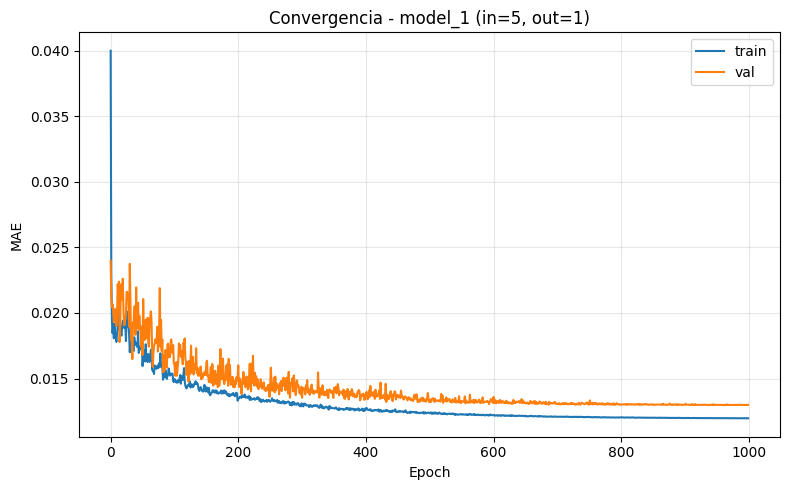

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(hist_1.history['loss'], label='train')
plt.plot(hist_1.history['val_loss'], label='val')

plt.title(f'Convergencia - model_1 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params   ep
conv_s     5      1 0.011973 0.012979 0.027551    5975 1000


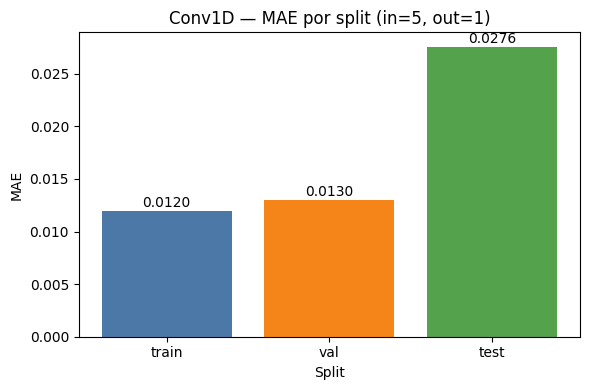

In [5]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_1.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 2

In [6]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_2 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_2 = model_2.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_2)

# Evaluación
result = {
    'train': eval_mae(model_2, X_tr, y_tr),
    'val':   eval_mae(model_2, X_v, y_v),
    'test':  eval_mae(model_2, X_ts, y_ts),
    'params': model_2.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_2.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out= 5 | train=0.0056 val=0.0046 test=0.0056 ep=1000


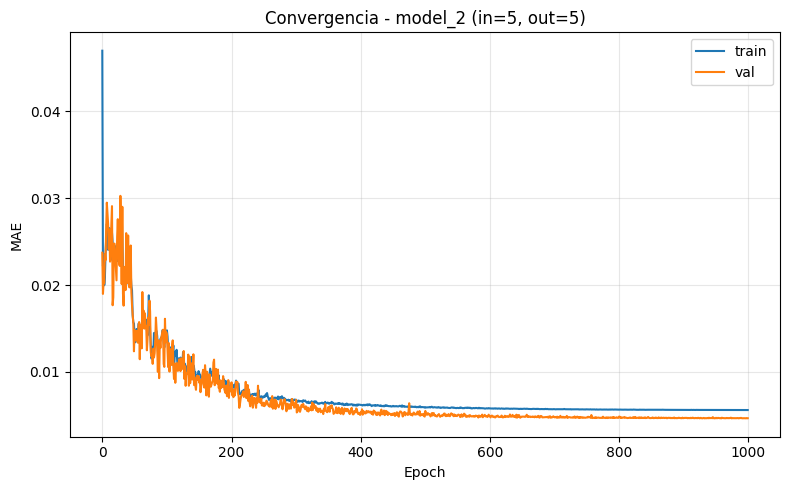

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(hist_2.history['loss'], label='train')
plt.plot(hist_2.history['val_loss'], label='val')

plt.title(f'Convergencia - model_2 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out   train      val     test  params   ep
conv_s     5      5 0.00558 0.004637 0.005601    5975 1000


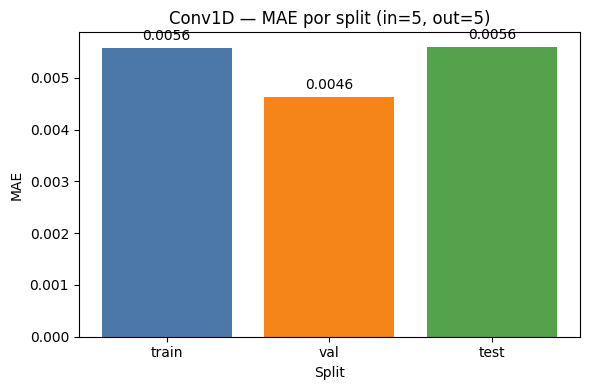

In [8]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_2.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 3

In [9]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_3 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_3.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_3 = model_3.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_3)

# Evaluación
result = {
    'train': eval_mae(model_3, X_tr, y_tr),
    'val':   eval_mae(model_3, X_v, y_v),
    'test':  eval_mae(model_3, X_ts, y_ts),
    'params': model_3.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_3.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=1000


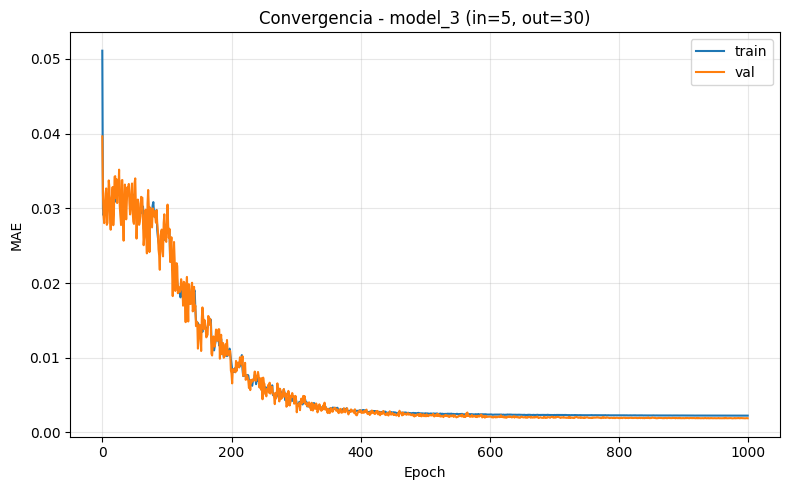

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(hist_3.history['loss'], label='train')
plt.plot(hist_3.history['val_loss'], label='val')

plt.title(f'Convergencia - model_3 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params   ep
conv_s     5     30 0.002249 0.001895 0.002326    5975 1000


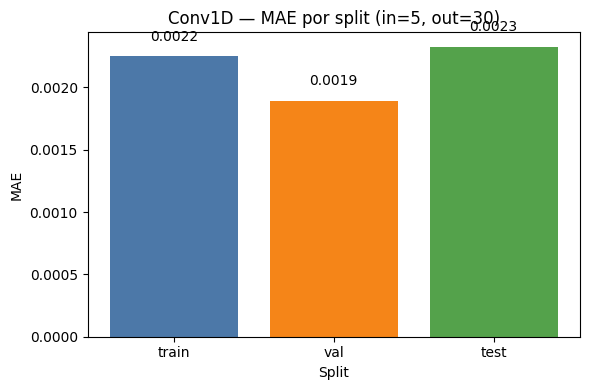

In [11]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_3.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 4

In [12]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_4 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_4.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_4 = model_4.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_4)

# Evaluación
result = {
    'train': eval_mae(model_4, X_tr, y_tr),
    'val':   eval_mae(model_4, X_v, y_v),
    'test':  eval_mae(model_4, X_ts, y_ts),
    'params': model_4.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_4.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=1000


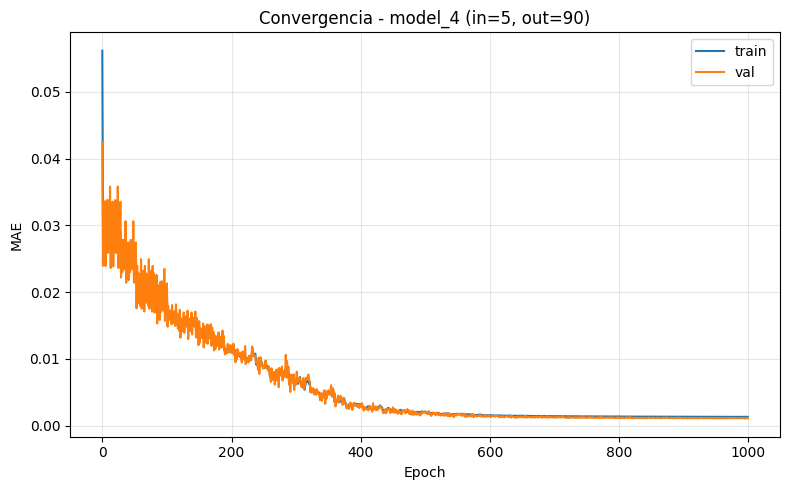

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(hist_4.history['loss'], label='train')
plt.plot(hist_4.history['val_loss'], label='val')

plt.title(f'Convergencia - model_4 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params   ep
conv_s     5     90 0.001295 0.001084 0.001281    5975 1000


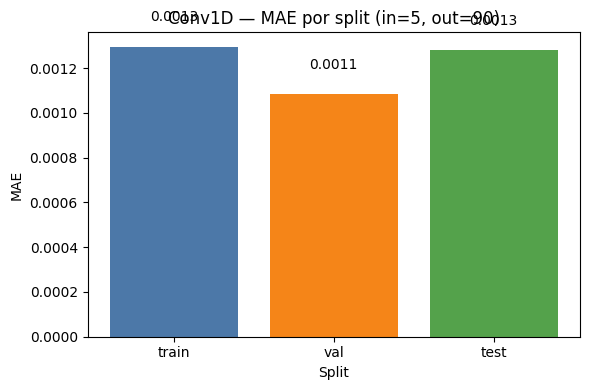

In [14]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_4.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 5

In [15]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_5 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_5.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_5 = model_5.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_5)

# Evaluación
result = {
    'train': eval_mae(model_5, X_tr, y_tr),
    'val':   eval_mae(model_5, X_v, y_v),
    'test':  eval_mae(model_5, X_ts, y_ts),
    'params': model_5.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_5.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out= 1 | train=0.0120 val=0.0122 test=0.0207 ep=1000


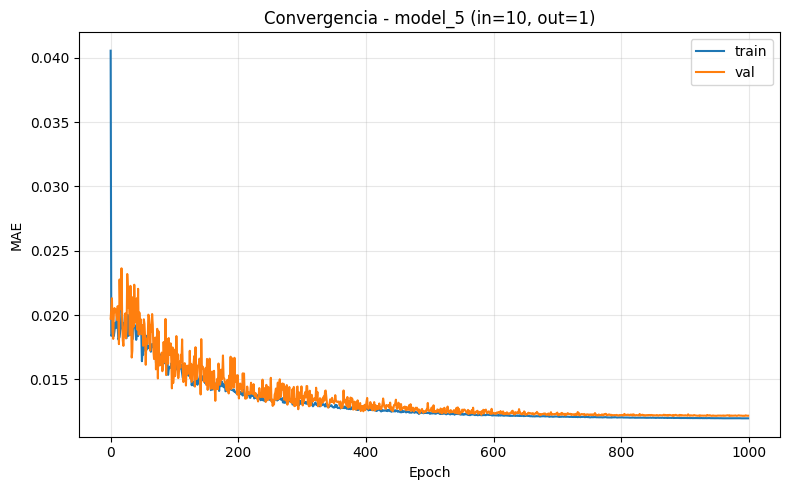

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(hist_5.history['loss'], label='train')
plt.plot(hist_5.history['val_loss'], label='val')

plt.title(f'Convergencia - model_5 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val    test  params   ep
conv_s    10      1 0.011968 0.012164 0.02071    5975 1000


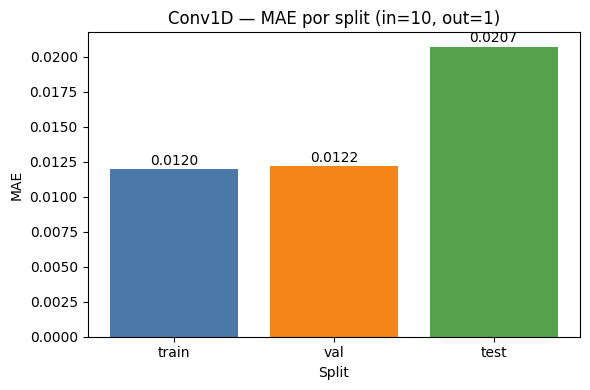

In [17]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_5.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 6

In [18]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_6 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_6.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_6 = model_6.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_6)

# Evaluación
result = {
    'train': eval_mae(model_6, X_tr, y_tr),
    'val':   eval_mae(model_6, X_v, y_v),
    'test':  eval_mae(model_6, X_ts, y_ts),
    'params': model_6.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_6.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out= 5 | train=0.0056 val=0.0046 test=0.0056 ep=1000


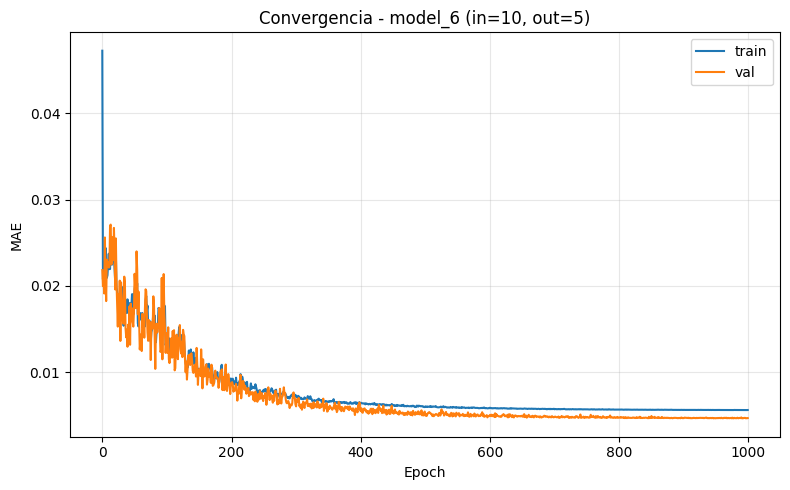

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(hist_6.history['loss'], label='train')
plt.plot(hist_6.history['val_loss'], label='val')

plt.title(f'Convergencia - model_6 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params   ep
conv_s    10      5 0.005586 0.004639 0.005608    5975 1000


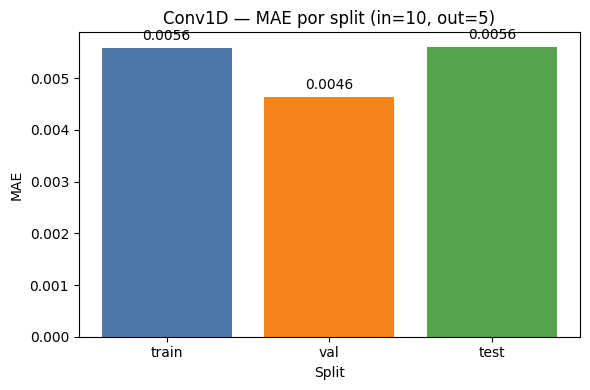

In [20]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_6.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 7

In [21]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_7 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_7.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_7 = model_7.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_7)

# Evaluación
result = {
    'train': eval_mae(model_7, X_tr, y_tr),
    'val':   eval_mae(model_7, X_v, y_v),
    'test':  eval_mae(model_7, X_ts, y_ts),
    'params': model_7.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_7.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=1000


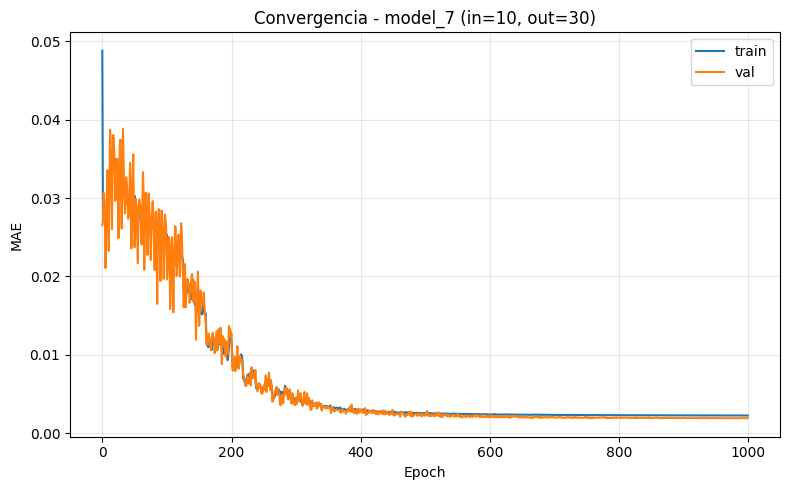

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(hist_7.history['loss'], label='train')
plt.plot(hist_7.history['val_loss'], label='val')

plt.title(f'Convergencia - model_7 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out   train      val     test  params   ep
conv_s    10     30 0.00225 0.001892 0.002329    5975 1000


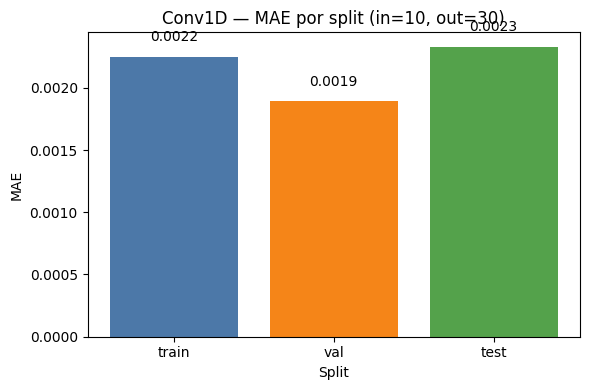

In [23]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_7.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 8

In [24]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_8 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_8.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_8 = model_8.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_8)

# Evaluación
result = {
    'train': eval_mae(model_8, X_tr, y_tr),
    'val':   eval_mae(model_8, X_v, y_v),
    'test':  eval_mae(model_8, X_ts, y_ts),
    'params': model_8.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_8.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=1000


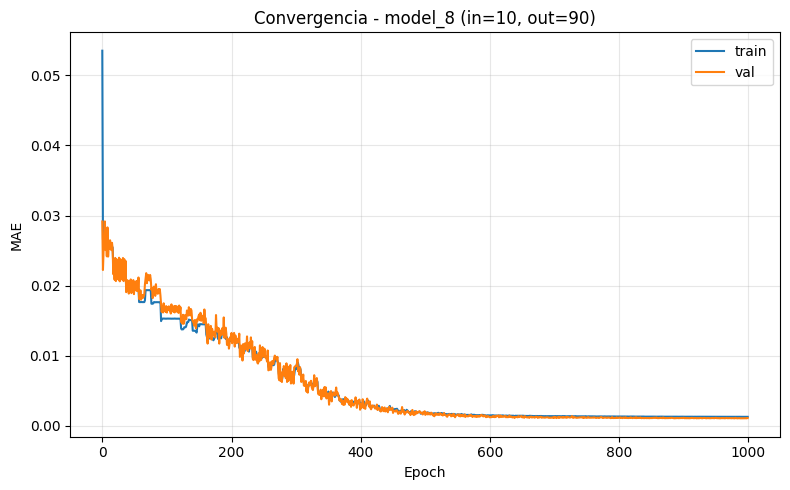

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(hist_8.history['loss'], label='train')
plt.plot(hist_8.history['val_loss'], label='val')

plt.title(f'Convergencia - model_8 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params   ep
conv_s    10     90 0.001301 0.001088 0.001284    5975 1000


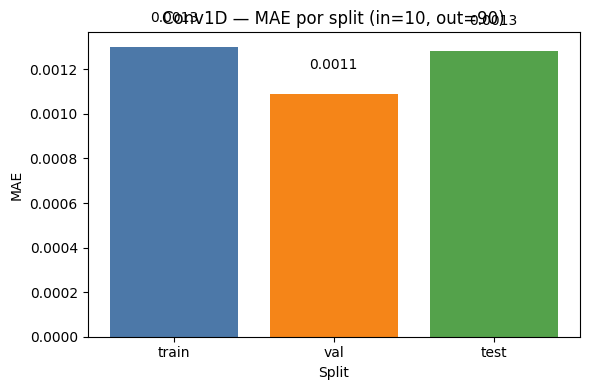

In [26]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_8.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 9

In [27]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_9 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_9.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_9 = model_9.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_9)

# Evaluación
result = {
    'train': eval_mae(model_9, X_tr, y_tr),
    'val':   eval_mae(model_9, X_v, y_v),
    'test':  eval_mae(model_9, X_ts, y_ts),
    'params': model_9.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_9.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=30 out= 1 | train=0.0120 val=0.0104 test=0.0123 ep=1000


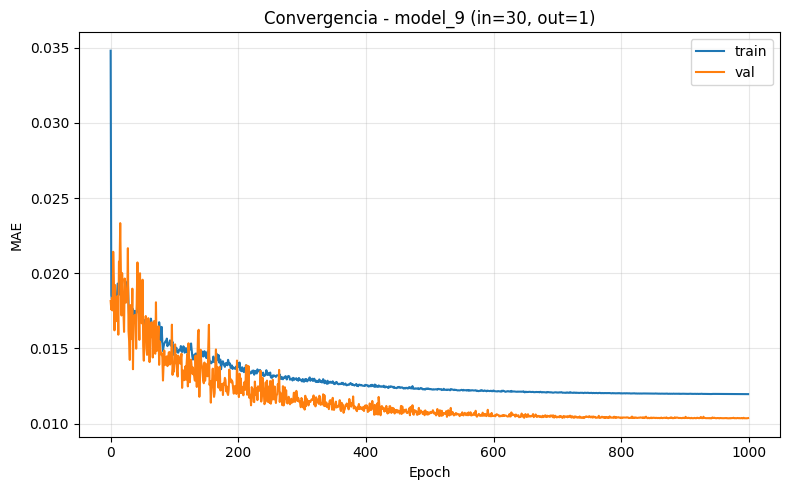

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(hist_9.history['loss'], label='train')
plt.plot(hist_9.history['val_loss'], label='val')

plt.title(f'Convergencia - model_9 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params   ep
conv_s    30      1 0.011972 0.010357 0.012291    5975 1000


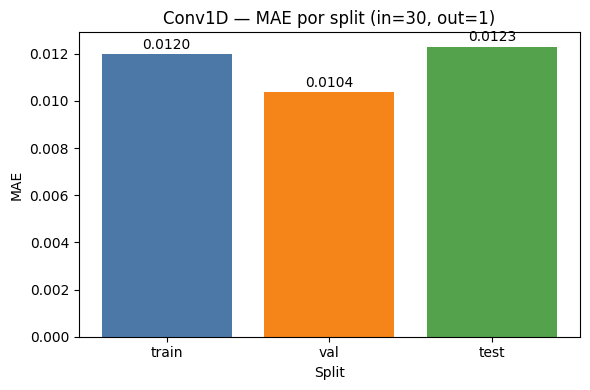

In [29]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_9.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 10 

In [30]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_10 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_10.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_10 = model_10.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_10)

# Evaluación
result = {
    'train': eval_mae(model_10, X_tr, y_tr),
    'val':   eval_mae(model_10, X_v, y_v),
    'test':  eval_mae(model_10, X_ts, y_ts),
    'params': model_10.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_10.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=30 out= 5 | train=0.0056 val=0.0061 test=0.0085 ep=1000


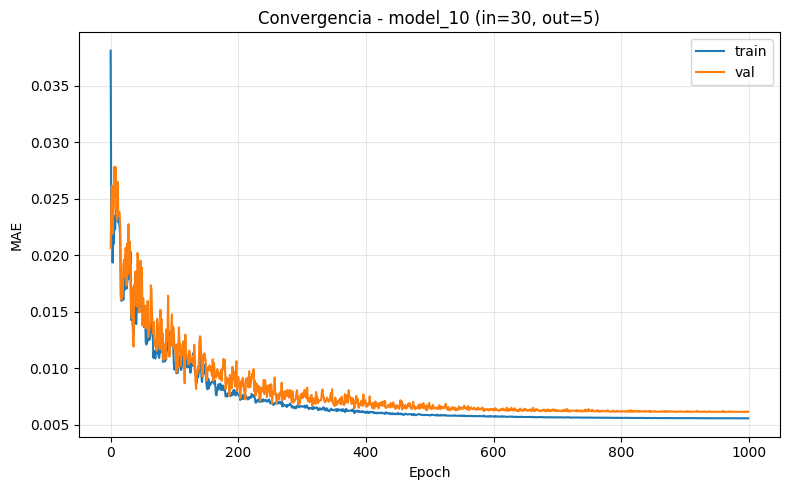

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(hist_10.history['loss'], label='train')
plt.plot(hist_10.history['val_loss'], label='val')

plt.title(f'Convergencia - model_10 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params   ep
conv_s    30      5 0.005581 0.006147 0.008452    5975 1000


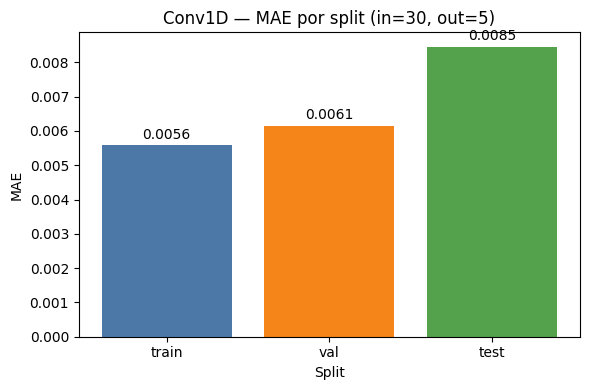

In [32]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_10.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 11 

In [33]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_11 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_11.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_11 = model_11.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_11)

# Evaluación
result = {
    'train': eval_mae(model_11, X_tr, y_tr),
    'val':   eval_mae(model_11, X_v, y_v),
    'test':  eval_mae(model_11, X_ts, y_ts),
    'params': model_11.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_11.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=30 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=1000


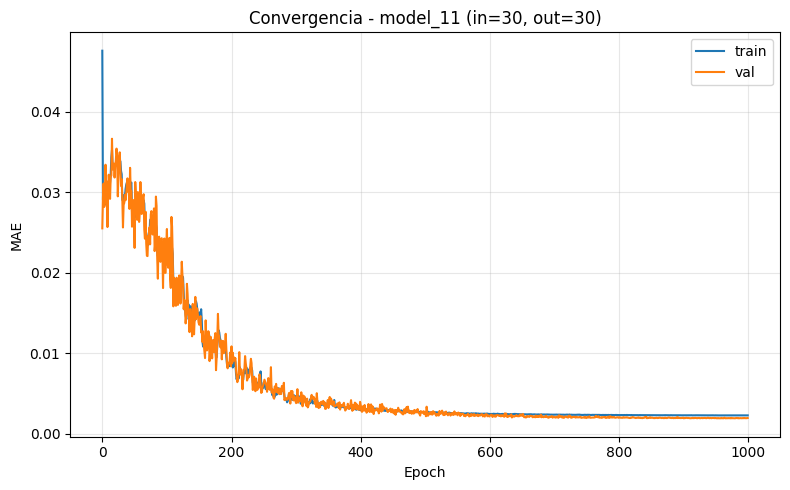

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(hist_11.history['loss'], label='train')
plt.plot(hist_11.history['val_loss'], label='val')

plt.title(f'Convergencia - model_11 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params   ep
conv_s    30     30 0.002248 0.001902 0.002327    5975 1000


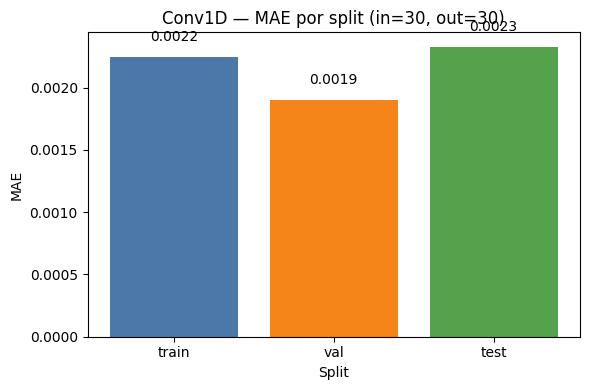

In [35]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_11.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 12

In [36]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_12 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_12.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_12 = model_12.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_12)

# Evaluación
result = {
    'train': eval_mae(model_12, X_tr, y_tr),
    'val':   eval_mae(model_12, X_v, y_v),
    'test':  eval_mae(model_12, X_ts, y_ts),
    'params': model_12.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_12.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=30 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=1000


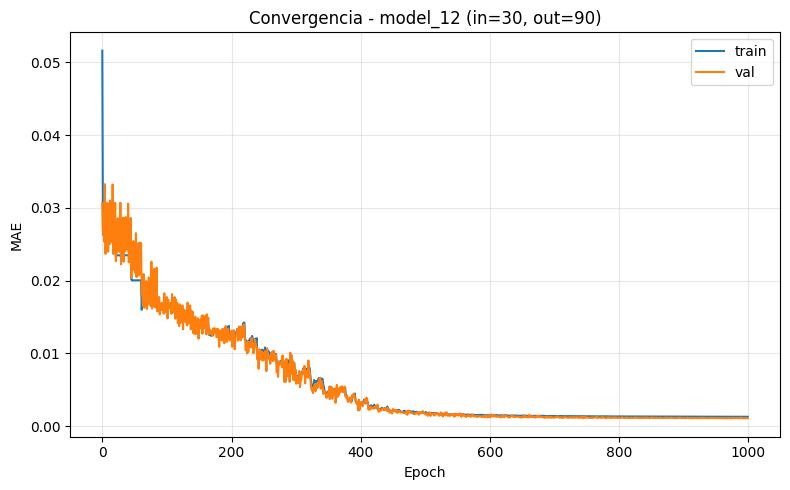

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(hist_12.history['loss'], label='train')
plt.plot(hist_12.history['val_loss'], label='val')

plt.title(f'Convergencia - model_12 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params   ep
conv_s    30     90 0.001284 0.001082 0.001281    5975 1000


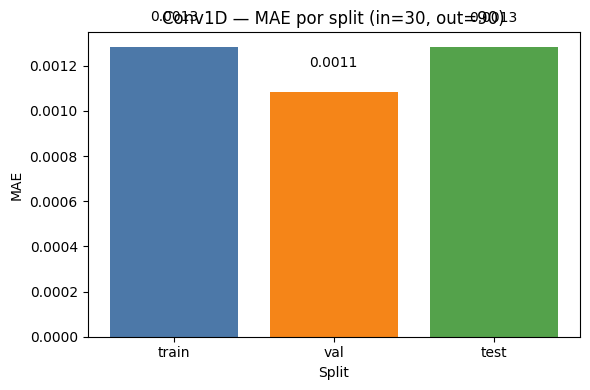

In [38]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_12.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 13

In [39]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_13 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_13.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_13 = model_13.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_13)

# Evaluación
result = {
    'train': eval_mae(model_13, X_tr, y_tr),
    'val':   eval_mae(model_13, X_v, y_v),
    'test':  eval_mae(model_13, X_ts, y_ts),
    'params': model_13.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_13.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=90 out= 1 | train=0.0120 val=0.0112 test=0.0178 ep=1000


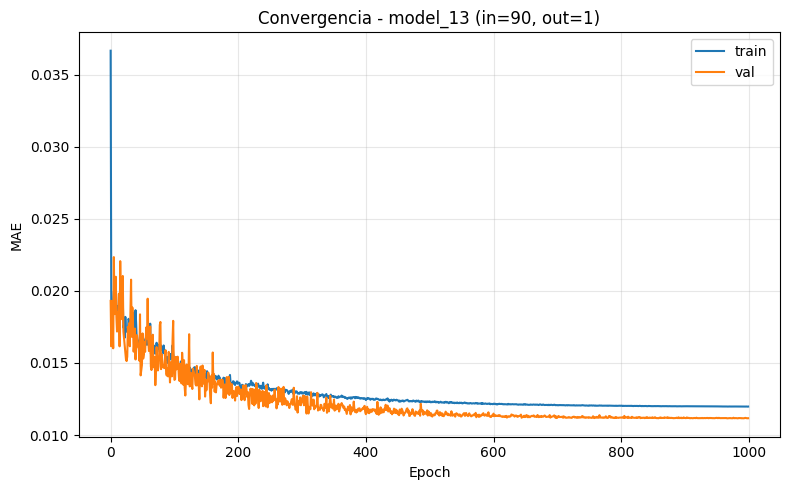

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(hist_13.history['loss'], label='train')
plt.plot(hist_13.history['val_loss'], label='val')

plt.title(f'Convergencia - model_13 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params   ep
conv_s    90      1 0.011977 0.011158 0.017793    5975 1000


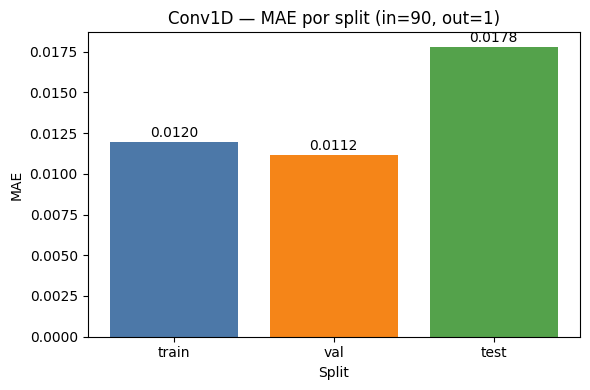

In [41]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_13.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 14

In [42]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_14 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_14.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_14 = model_14.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_14)

# Evaluación
result = {
    'train': eval_mae(model_14, X_tr, y_tr),
    'val':   eval_mae(model_14, X_v, y_v),
    'test':  eval_mae(model_14, X_ts, y_ts),
    'params': model_14.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_14.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=90 out= 5 | train=0.0056 val=0.0046 test=0.0056 ep=1000


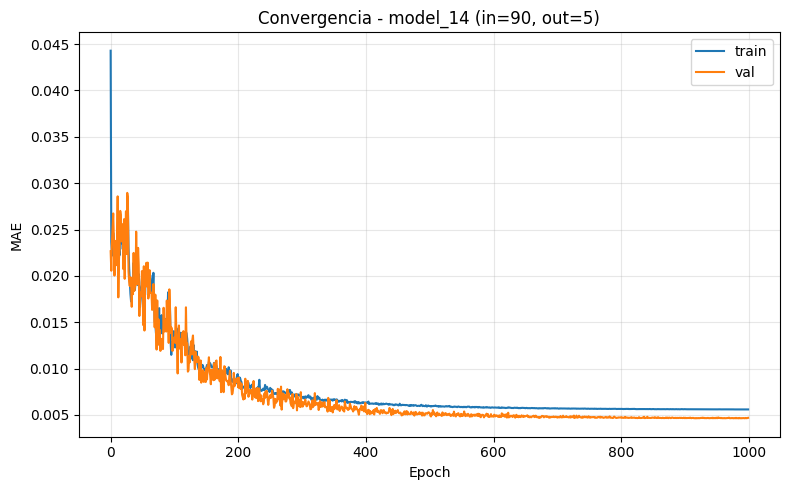

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(hist_14.history['loss'], label='train')
plt.plot(hist_14.history['val_loss'], label='val')

plt.title(f'Convergencia - model_14 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params   ep
conv_s    90      5 0.005596 0.004638 0.005619    5975 1000


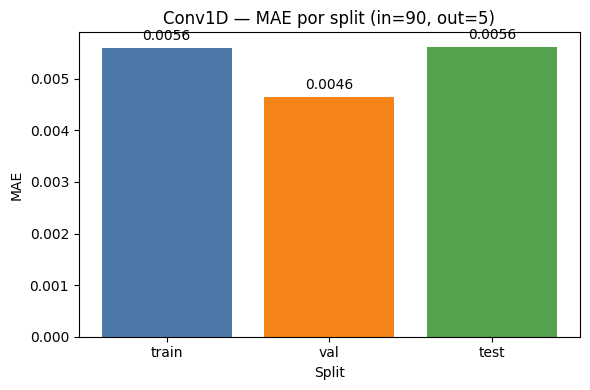

In [44]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_14.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 15

In [45]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_15 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_15.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_15 = model_15.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_15)

# Evaluación
result = {
    'train': eval_mae(model_15, X_tr, y_tr),
    'val':   eval_mae(model_15, X_v, y_v),
    'test':  eval_mae(model_15, X_ts, y_ts),
    'params': model_15.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_15.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=90 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=1000


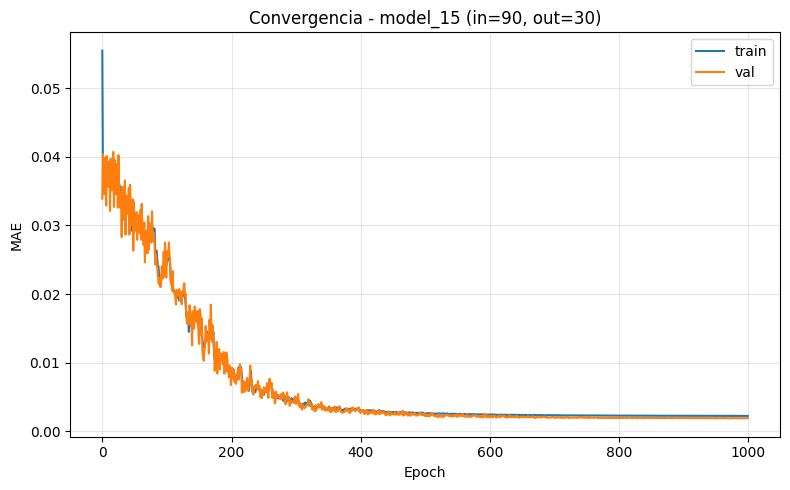

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(hist_15.history['loss'], label='train')
plt.plot(hist_15.history['val_loss'], label='val')

plt.title(f'Convergencia - model_15 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params   ep
conv_s    90     30 0.002244 0.001896 0.002338    5975 1000


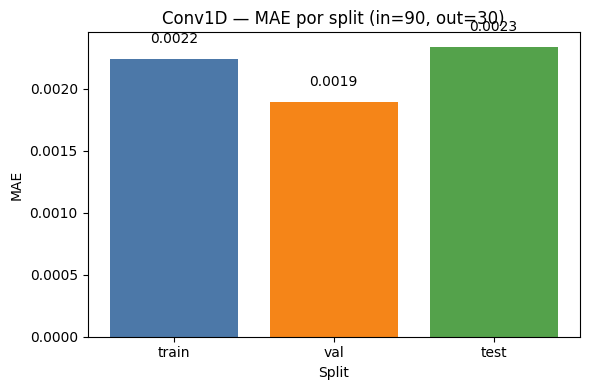

In [47]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_15.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 16

In [48]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 90  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000001

model_16 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_16.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_16 = model_16.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_16)

# Evaluación
result = {
    'train': eval_mae(model_16, X_tr, y_tr),
    'val':   eval_mae(model_16, X_v, y_v),
    'test':  eval_mae(model_16, X_ts, y_ts),
    'params': model_16.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_16.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=90 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=1000


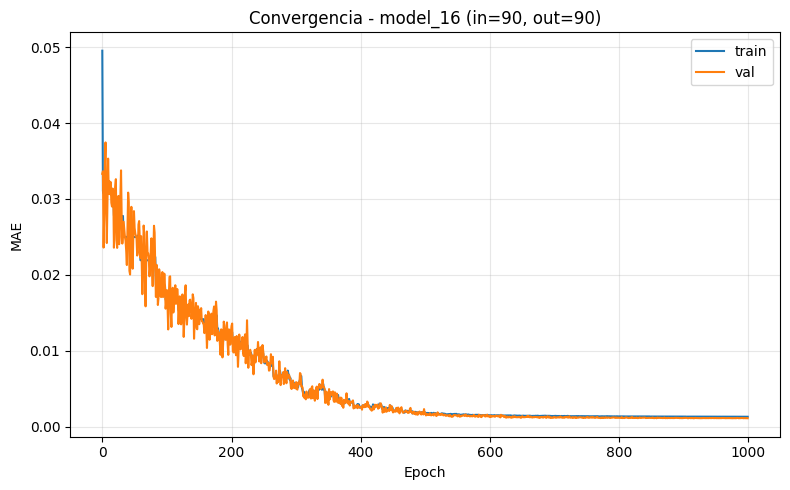

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(hist_16.history['loss'], label='train')
plt.plot(hist_16.history['val_loss'], label='val')

plt.title(f'Convergencia - model_16 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train     val     test  params   ep
conv_s    90     90 0.001284 0.00108 0.001275    5975 1000


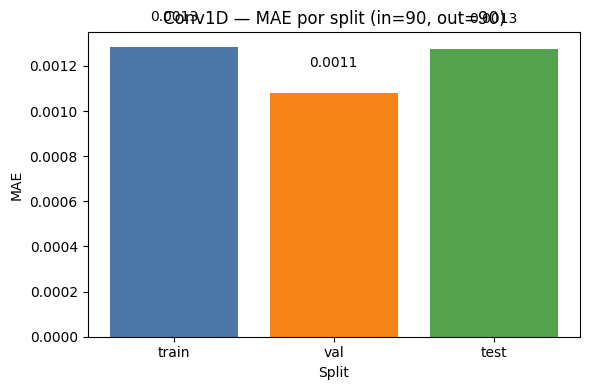

In [50]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_16.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Resumen de resultados de los Modelos Implementados

,modelo,V_in,V_out,train,val,test,params
0,1,5,1,0.0120,0.0130,0.0276,5975
1,2,5,5,0.0056,0.0046,0.0056,5975
2,3,5,30,0.0022,0.0019,0.0023,5975
3,4,5,90,0.0013,0.0011,0.0013,5975
4,5,10,1,0.0120,0.0122,0.0207,5975
5,6,10,5,0.0056,0.0046,0.0056,5975
6,7,10,30,0.0022,0.0019,0.0023,5975
7,8,10,90,0.0013,0.0011,0.0013,5975
8,9,30,1,0.0120,0.0104,0.0123,5975
9,10,30,5,0.0056,0.0061,0.0085,5975


Conv1D - MAE train


,1,5,30,90
5,0.012,0.0056,0.0022,0.0013
10,0.012,0.0056,0.0022,0.0013
30,0.012,0.0056,0.0022,0.0013
90,0.012,0.0056,0.0022,0.0013


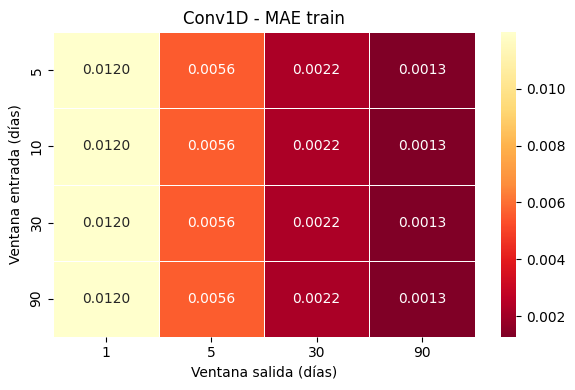

Conv1D - MAE val


,1,5,30,90
5,0.0130,0.0046,0.0019,0.0011
10,0.0122,0.0046,0.0019,0.0011
30,0.0104,0.0061,0.0019,0.0011
90,0.0112,0.0046,0.0019,0.0011


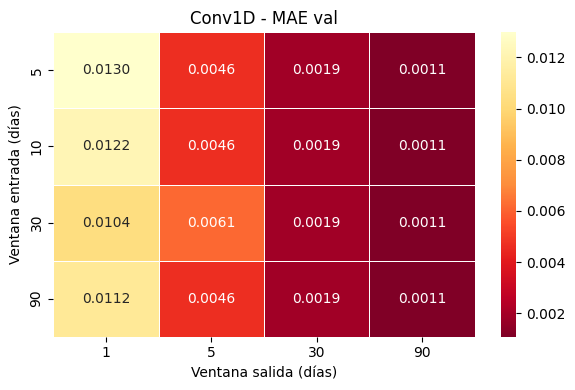

Conv1D - MAE test


,1,5,30,90
5,0.0276,0.0056,0.0023,0.0013
10,0.0207,0.0056,0.0023,0.0013
30,0.0123,0.0085,0.0023,0.0013
90,0.0178,0.0056,0.0023,0.0013


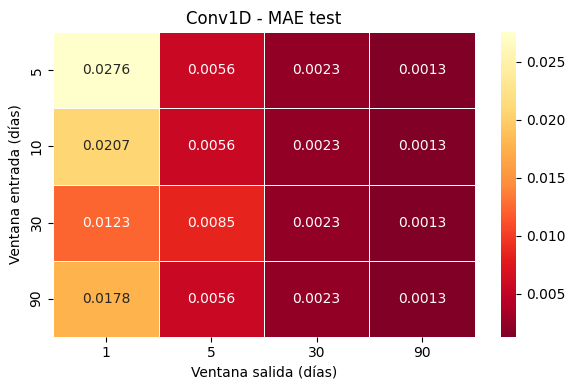

In [51]:
# Resumen global de los 16 modelos ya entrenados
model_specs = {
    idx: (V_in_t, V_out_t)
    for idx, (V_in_t, V_out_t) in enumerate(
        [(vi, vo) for vi in INPUT_WINDOWS for vo in OUTPUT_WINDOWS],
        start=1
    )
}

missing_models = [
    f'model_{idx}'
    for idx in model_specs
    if f'model_{idx}' not in globals()
]

if missing_models:
    raise ValueError(
        'Faltan modelos en memoria. Ejecuta antes las 16 celdas de entrenamiento: ' +
        ', '.join(missing_models)
    )

split_mats = {
    split: pd.DataFrame(index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS, dtype=float)
    for split in ['train', 'val', 'test']
}

rows = []

for idx, (V_in_t, V_out_t) in model_specs.items():
    model = globals()[f'model_{idx}']

    X, y = create_time_series_data(returns, V_in_t, V_out_t)
    X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

    scores = {
        'train': eval_mae(model, X_tr, y_tr),
        'val':   eval_mae(model, X_v,  y_v),
        'test':  eval_mae(model, X_ts, y_ts),
    }

    for split, value in scores.items():
        split_mats[split].loc[V_in_t, V_out_t] = value

    rows.append({
        'modelo': idx,
        'V_in': V_in_t,
        'V_out': V_out_t,
        'train': scores['train'],
        'val': scores['val'],
        'test': scores['test'],
        'params': model.count_params(),
    })

df_conv_resumen = pd.DataFrame(rows).sort_values('modelo').reset_index(drop=True)
display(df_conv_resumen.round(4))

for split in ['train', 'val', 'test']:
    print(f'Conv1D - MAE {split}')
    display(split_mats[split].round(4))
    plot_mae_matrix(split_mats[split], title=f'Conv1D - MAE {split}')
